# Exploratory Data Analysis and Sampling Strategy

## Project Objective
The objective of this analysis is to examine the academic, lifestyle, and behavioral factors associated with student depression and to support the development of an interpretable machine learning model that can predict depression risk.

## Target Variable
The target variable for this analysis is `depression`.

## Research Question
Which behavioral and mental factors are most strongly associated with depression among students, and how effectively can these factors be used to predict depression risk?

## Hypotheses

### Main Hypothesis
Behavioral factors are significantly associated with student depression and can be used to predict depression risk.

## Step 1: Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load the Dataset

In [5]:
df = pd.read_csv(r"college_students_habits_1M.csv")

## Step 3: Inspect the Dataset Structure


In [6]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1000000, 42)

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']

First 5 rows:
   study_hours  attendance  assignment_completion  midterm_score  final_score  \
0     3.014684    67.00599              51.595387      57.211285    61.6535

## Step 4: Define the Target Variable
This target will be examined to determine whether the problem should be treated as classification or regression.

In [7]:
target_col = "depression"
print("Target column:", target_col)

Target column: depression


## Step 5: Check Missing Values
Missing values are examined to understand the quality of the dataset and to determine whether preprocessing is needed before sampling and deeper analysis.

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours 

## Step 6: Check for Duplicate Rows
Duplicate rows are checked because they may bias the analysis and affect the representativeness of the sample.

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Step 7: Examine the Target Variable
This step is used to understand the nature of the target variable.
If the target has many numeric values, the problem is treated as regression.
If the target contains a few categories, the problem is treated as classification.

In [10]:
print("Target data type:", df[target_col].dtype)
print("\nNumber of unique values in target:", df[target_col].nunique())

print("\nTarget summary statistics:")
print(df[target_col].describe())

Target data type: float64

Number of unique values in target: 964263

Target summary statistics:
count    1000000.000000
mean          44.991453
std           14.991202
min            0.000000
25%           34.862051
50%           44.973913
75%           55.099820
max          100.000000
Name: depression, dtype: float64


## Step 8: Visualize the Distribution of the Target
A histogram is plotted to understand the distribution of depression values.
This helps determine whether the target is continuous and whether the distribution is skewed or approximately normal.

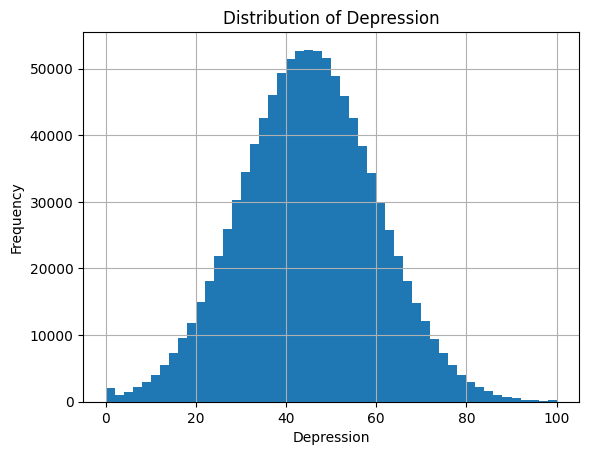

In [11]:
df[target_col].hist(bins=50)
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.show()

## Step 10: Check for Time Structure
This step checks whether the dataset contains time-related columns such as dates or timestamps.
If such columns exist and row order matters, time-based sampling may be required.

In [12]:
time_cols = [c for c in df.columns if any(k in c.lower() for k in ['date','time','year','month','week'])]
print("Time-related columns:", time_cols)

Time-related columns: ['time_management', 'screen_time', 'part_time_hours', 'weekly_study_sessions']


## Step 11: Check for Group Structure
This step checks whether the dataset contains identifier columns such as `student_id`, `user_id`, or `customer_id`.
If multiple rows belong to the same entity, group-aware sampling may be necessary.

In [13]:
id_cols = [c for c in df.columns if any(k in c.lower() for k in ['id','student','user','customer'])]
print("ID-like columns:", id_cols)

ID-like columns: ['midterm_score', 'hostel_student']


## Overall Conclusion 

Through the initial stages of data inspection and preprocessing, several key observations were made about the dataset:

### Data Quality and Structure
- The dataset contains approximately 1 million rows and a wide range of academic, lifestyle, and behavioral features.
- Most features have no missing values, indicating high data quality.
- No duplicate rows were found, confirming that each observation is unique.
- Some features were identified as redundant or non-informative , and these were considered for removal.

### Target Variable Analysis
- The target variable `depression` is numerical (float64) with a very large number of unique values.
- Its distribution is continuous and approximately normal, ranging between 0 and 100.
- Based on these characteristics, the problem is treated as a **regression task**, but, it will be converted into binary, so the problem will be treated as a binary classification.

### Data Independence
- No time-related features (such as timestamps or dates) are present, indicating that the dataset has no temporal structure.
- No identifier columns (such as student IDs) were found, suggesting that each row represents an independent observation.
- Therefore, the data can be considered independent and identically distributed (i.i.d.).

### Final Implications for Sampling
- Since there is no time structure, time-based sampling is unnecessary.
- Since there is no group structure, group-aware sampling is not needed.

### Final Decision
- Based on all the above observations, **simple random sampling** is the most appropriate method.
- A random subset of 100,000 rows can be selected while preserving the statistical properties of the full dataset.

## Step 12: Apply Simple Random Sampling
Simple random sampling is applied to select a representative subset of the dataset.

In [14]:
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

Original shape: (1000000, 42)
Sample shape: (100000, 42)


## Step 13: Validate the Sample
The sample is compared to the full dataset using summary statistics of the target variable.
If the statistics are close, the sample can be considered reasonably representative.

In [15]:
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

print("\nOriginal depression mean:", df[target_col].mean())
print("Sample depression mean:", df_sample[target_col].mean())

print("\nOriginal depression std:", df[target_col].std())
print("Sample depression std:", df_sample[target_col].std())

Original shape: (1000000, 42)
Sample shape: (100000, 42)

Original depression mean: 44.99145297219754
Sample depression mean: 44.951999642673805

Original depression std: 14.991202051679972
Sample depression std: 15.055963305613217


## Step 14: Compare the Original and Sample Distributions
A visual comparison is made between the target distribution in the original dataset and in the sampled dataset.
This helps confirm whether the sample preserves the overall shape of the data.

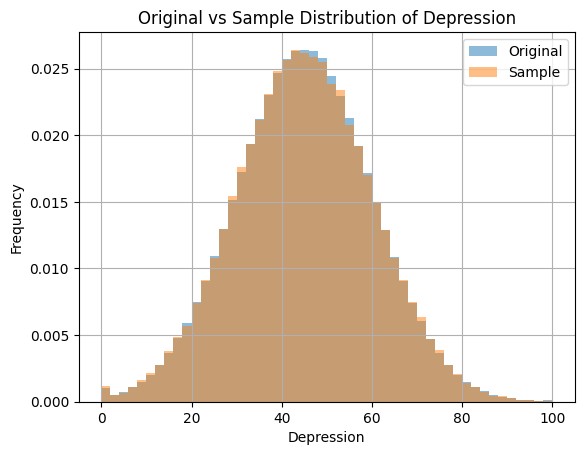

In [53]:
df[target_col].hist(bins=50, alpha=0.5, label="Original", density=True)
df_sample[target_col].hist(bins=50, alpha=0.5, label="Sample", density=True)
plt.title("Original vs Sample Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Conclusion

The sampled dataset preserves the distribution of the target variable and remains clean, with no duplicate rows or meaningful missing-value issues. Therefore, it is suitable for the next stage of exploratory data analysis.

## Step 15: Detect Potential Outliers in Numerical Features

In this step, we examine the sampled dataset for potential outliers in numerical predictor variables using the Interquartile Range (IQR) method.

In [17]:
def find_outliers_iqr(df, cols):
    report = {}
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        
        report[col] = {
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": n_out
        }
    
    return pd.DataFrame(report).T

# Select numeric predictor columns only
numeric_cols = df_sample.select_dtypes(include="number").columns.tolist()
numeric_cols.remove("depression")  # exclude target variable

# Generate outlier report
outlier_report = find_outliers_iqr(df_sample, numeric_cols)

# Show only features with detected outliers
print(outlier_report[outlier_report["outlier_count"] > 0].sort_values(by="outlier_count", ascending=False))

                          lower_bound   upper_bound  outlier_count
parental_education_level     0.500000      4.500000         4545.0
family_income            -9390.340625  56617.598375         4046.0
time_management              3.319166      8.682832          756.0
self_discipline              3.319166      8.682832          756.0
caffeine_mg                108.284813    255.929172          723.0
sleep_hours                  5.328208      7.672894          718.0
motivation                   3.392314      8.610459          716.0
internet_quality             2.290133      7.706654          704.0
junk_food_frequency          0.310583      5.695888          703.0
physical_activity            1.304112      6.689417          703.0
concentration                3.042713      8.969210          693.0
extracurricular_hours        0.302311      5.695303          688.0
weekly_study_sessions        0.287340      5.716500          686.0
financial_stress             1.355222      8.633473          6

### Conclusion
Outlier detection was performed using the IQR method (1.5× fence) across all numeric features. The majority of flagged outliers are artifacts of applying IQR to bounded, non-normally distributed features (e.g., 0–10 scale scores) rather than genuine data errors. The ~700 flags per bounded feature (<1% of 100,000 rows) reflect natural tail values, not anomalies.

## Step 16: Create a correlation matrix, analyze features relations with depression

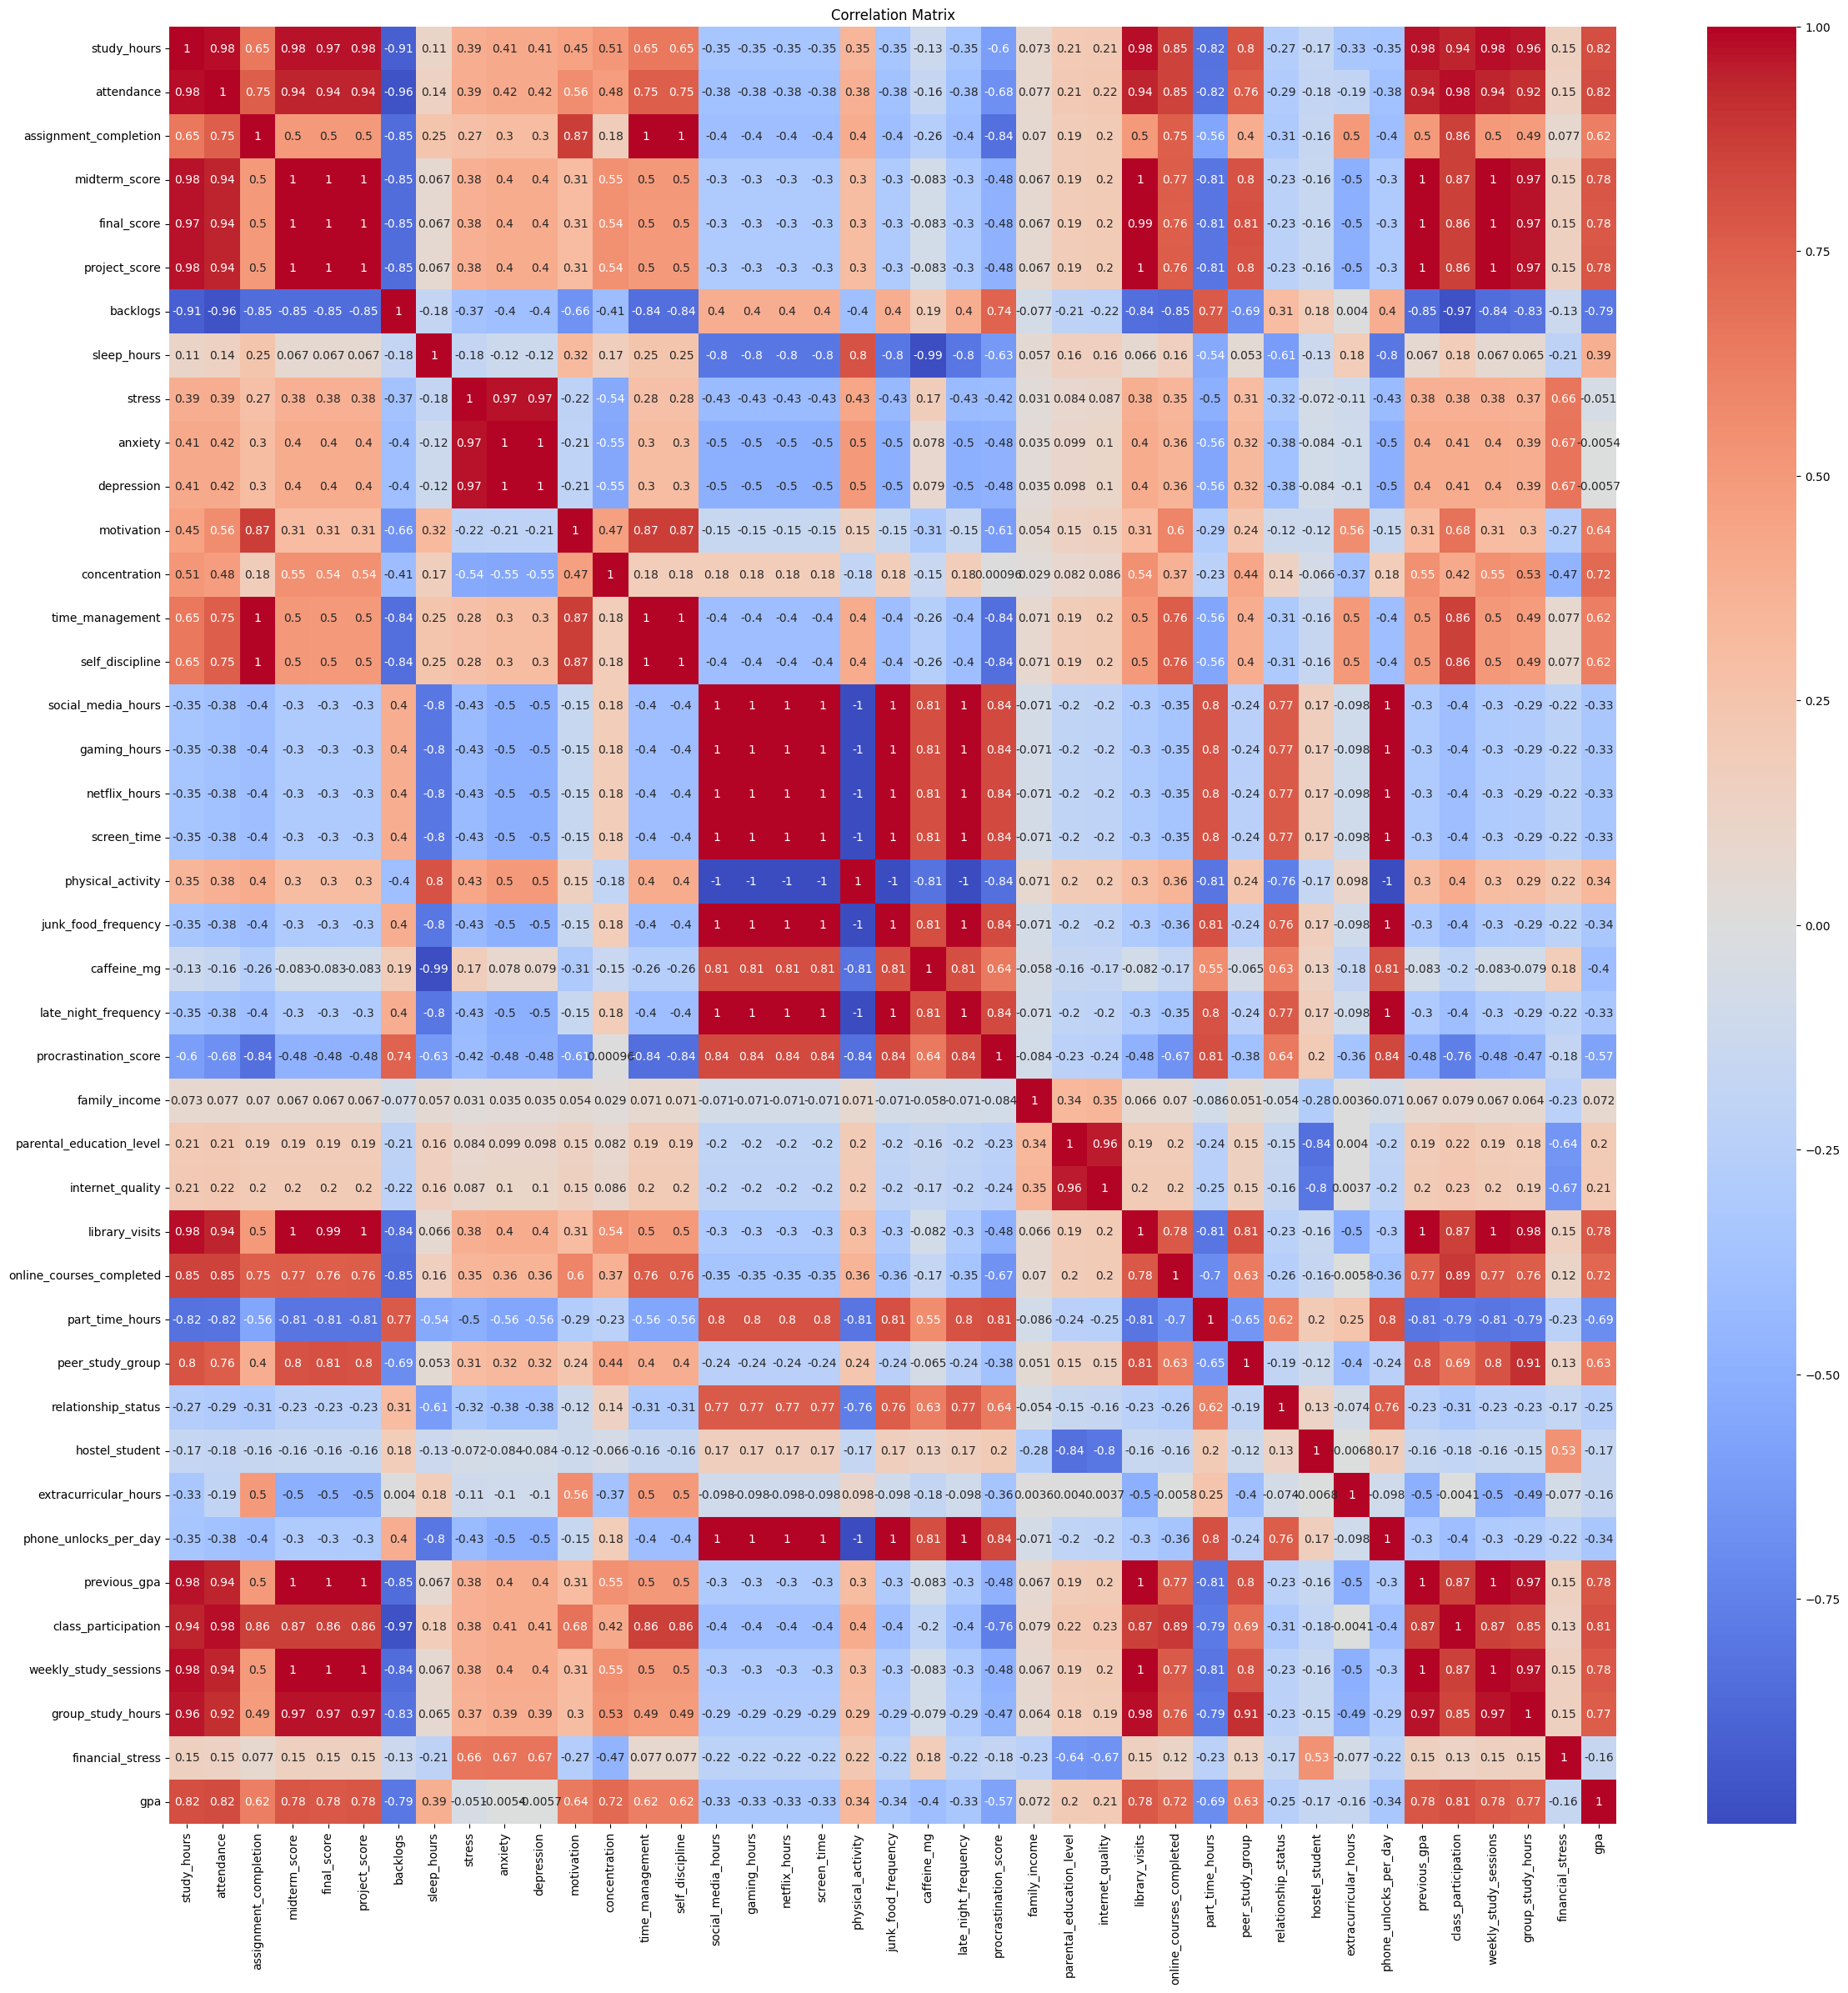

In [18]:

corr = df_sample.corr(numeric_only=True)

plt.figure(figsize=(28,28))
sns.heatmap(corr, cmap="coolwarm",annot=True)
plt.title("Correlation Matrix")
plt.show()

## Step 17: Examine Relationships Between Numerical Features and Depression

In this step, the numerical features are compared with the target variable (`depression`) using correlation analysis. This helps identify which academic, lifestyle, and behavioral factors are most strongly associated with depression and provides an initial direction for deeper exploratory analysis and modeling.

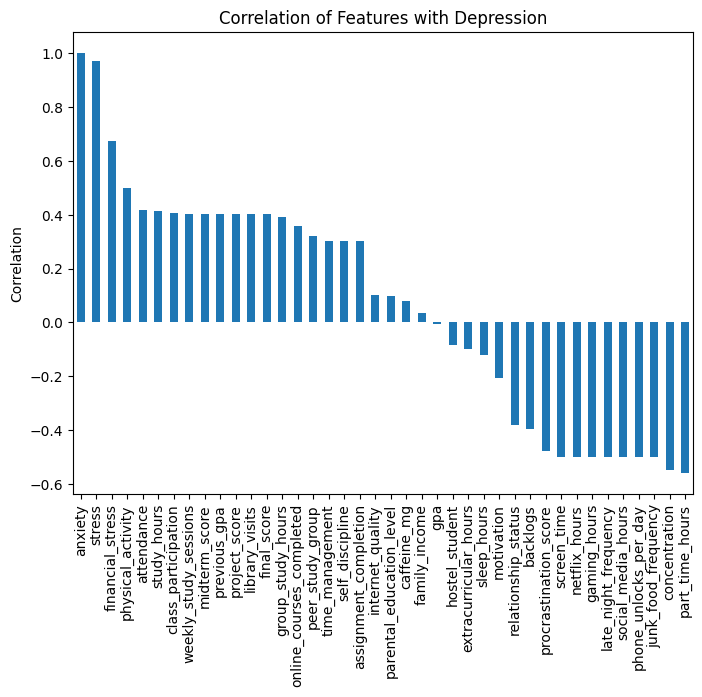

In [19]:
corr_target = df_sample.corr(numeric_only=True)["depression"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
corr_target.drop("depression").plot(kind="bar")
plt.title("Correlation of Features with Depression")
plt.ylabel("Correlation")
plt.show()

### Conclusion

The correlation analysis shows that several academic, lifestyle, and behavioral variables are associated with depression.

The strongest positive correlations with `depression` appear in variables such as `anxiety`, `stress`, and `financial_stress`, suggesting that higher psychological and financial pressure may be linked to higher depression levels.

Moderate positive relationships are also observed for variables related to reduced well-being or academic difficulty.

Negative correlations are observed for variables such as `sleep_hours`, `concentration`, and `part_time_hours`, indicating that higher values in these features may be associated with lower depression levels in this dataset.

Overall, these findings are consistent with the project objective of identifying the factors most associated with student depression. However, the results should be interpreted carefully because some variables may be highly related to each other or may reflect overlapping constructs.

## Step 18: Handle Redundant Features and Check for Potential Leakage

In this step, the sampled dataset is reviewed for highly correlated, duplicated, or derived features that may distort interpretation and modeling.

The goal is to improve the quality of the feature set by:

- removing clearly redundant variables
- avoiding features that duplicate the same information
- checking whether some predictors are unrealistically close to the target variable

### Important Note

A high correlation with the target does not automatically mean that a feature is leakage. Some variables may be legitimate predictors. However, if a feature is nearly identical to the target or appears to be generated from the same underlying formula, it can make the model unrealistically easy and reduce its usefulness.

### Redundant Academic Score Features

The dataset already contains a `gpa` feature, which represents overall academic performance. Since `midterm_score`, `final_score`, and `project_score` are strongly related academic score variables, keeping all of them may introduce unnecessary multicollinearity.

To simplify the feature space, the existing `gpa` variable is retained and the individual score components are removed.

In [20]:
print(df_sample["performance_level"].nunique())
print(df_sample["performance_level"].value_counts(dropna=False))


1
performance_level
Low    99851
NaN      149
Name: count, dtype: int64


In [21]:
print((df_sample["time_management"] == df_sample["self_discipline"]).all())
print((df_sample["gaming_hours"] == df_sample["netflix_hours"]).all())
print((df_sample["gaming_hours"] == df_sample["late_night_frequency"]).all())

True
True
True


In [22]:
reconstructed = df_sample["social_media_hours"] + df_sample["gaming_hours"] + df_sample["netflix_hours"]
diff = df_sample["screen_time"] - reconstructed

print("Mean absolute difference:", diff.abs().mean())
print("Max absolute difference:", diff.abs().max())
print("Exact / near-exact match ratio:", (diff.abs() < 1e-6).mean())

Mean absolute difference: 2.2107498205672193e-07
Max absolute difference: 2.0000000020559128e-06
Exact / near-exact match ratio: 0.99192


In [23]:
# Remove redundant academic score features
df_sample.drop(columns=[
    "midterm_score",
    "final_score",
    "project_score"
], inplace=True)

### Engineered Behavioral Features

After reducing redundancy, a small number of composite features are created to summarize related behavioral patterns.

These engineered variables are heuristic summaries intended to capture broader tendencies, not exact scientific scales. They are created for exploratory purposes and may later be evaluated during modeling.

In [24]:
# Create exploratory composite features
df_sample["healthy_lifestyle"] = (
    df_sample["physical_activity"] * 2
    + df_sample["sleep_hours"]
    - df_sample["junk_food_frequency"] / 5
    - df_sample["caffeine_mg"] / 100
)

df_sample["risk_behavior"] = (
    df_sample["procrastination_score"]
    + df_sample["late_night_frequency"]
)

df_sample["sleep_disruption"] = (
    df_sample["late_night_frequency"] * (8 - df_sample["sleep_hours"])
)

### Re-check Correlations After Feature Cleaning

After removing redundant variables and creating composite features, the correlation structure is re-examined to identify:

- the strongest remaining relationships with `depression`
- any features with near-zero linear association
- any suspiciously extreme correlations that may indicate potential leakage

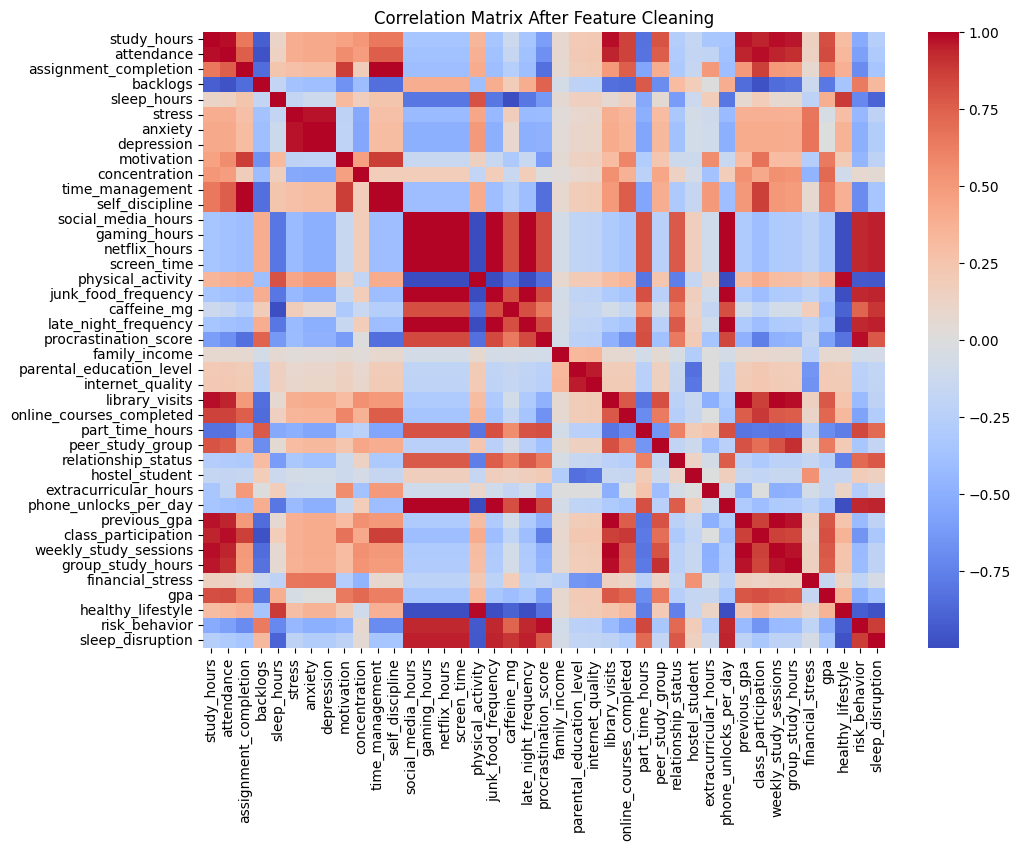

In [25]:
# Recompute correlations after feature updates
corr = df_sample.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix After Feature Cleaning")
plt.show()

In [26]:
# Correlation with target (signed)
corr_with_target = df_sample.corr(numeric_only=True)["depression"].sort_values()
print("Correlation with depression:")
print(corr_with_target)

Correlation with depression:
part_time_hours            -0.558117
concentration              -0.548257
risk_behavior              -0.505618
junk_food_frequency        -0.498954
phone_unlocks_per_day      -0.498818
social_media_hours         -0.498113
netflix_hours              -0.498113
late_night_frequency       -0.498113
gaming_hours               -0.498113
screen_time                -0.498113
procrastination_score      -0.478470
backlogs                   -0.396413
relationship_status        -0.380367
sleep_disruption           -0.274546
motivation                 -0.205467
sleep_hours                -0.120941
extracurricular_hours      -0.100150
hostel_student             -0.083667
gpa                        -0.005653
family_income               0.035473
caffeine_mg                 0.078884
parental_education_level    0.098422
internet_quality            0.101708
assignment_completion       0.301938
time_management             0.302584
self_discipline             0.302584
peer_stud

In [27]:
# Absolute correlation with target
abs_corr_with_target = (
    df_sample.corr(numeric_only=True)["depression"]
    .abs()
    .sort_values(ascending=False)
)

print("\nAbsolute correlation with depression:")
print(abs_corr_with_target)


Absolute correlation with depression:
depression                  1.000000
anxiety                     0.999951
stress                      0.969995
financial_stress            0.671290
part_time_hours             0.558117
concentration               0.548257
risk_behavior               0.505618
physical_activity           0.498993
junk_food_frequency         0.498954
phone_unlocks_per_day       0.498818
social_media_hours          0.498113
netflix_hours               0.498113
gaming_hours                0.498113
late_night_frequency        0.498113
screen_time                 0.498113
procrastination_score       0.478470
attendance                  0.416832
study_hours                 0.414494
class_participation         0.406154
weekly_study_sessions       0.401499
previous_gpa                0.401464
library_visits              0.400782
backlogs                    0.396413
group_study_hours           0.391348
relationship_status         0.380367
healthy_lifestyle           0.364868

                              mean       std      min        max  skewness  \
gpa                           0.83      0.30     0.00       2.00      0.04   
class_participation           5.01      1.72     1.00      10.00      0.05   
study_hours                   4.04      2.22     0.00      12.00      0.20   
attendance                   74.88     12.91    30.00     100.00     -0.15   
assignment_completion        69.88     14.69    20.00     100.00     -0.12   
backlogs                      2.55      1.65     0.00      10.00      0.31   
sleep_hours                   6.50      0.44     4.54       8.48      0.01   
depression                   44.95     15.06     0.00     100.00      0.01   
motivation                    6.00      0.97     1.66      10.00      0.00   
concentration                 6.01      1.10     1.18      10.00      0.00   
self_discipline               6.00      1.00     1.41      10.00     -0.01   
social_media_hours            3.02      1.47     0.00       9.42

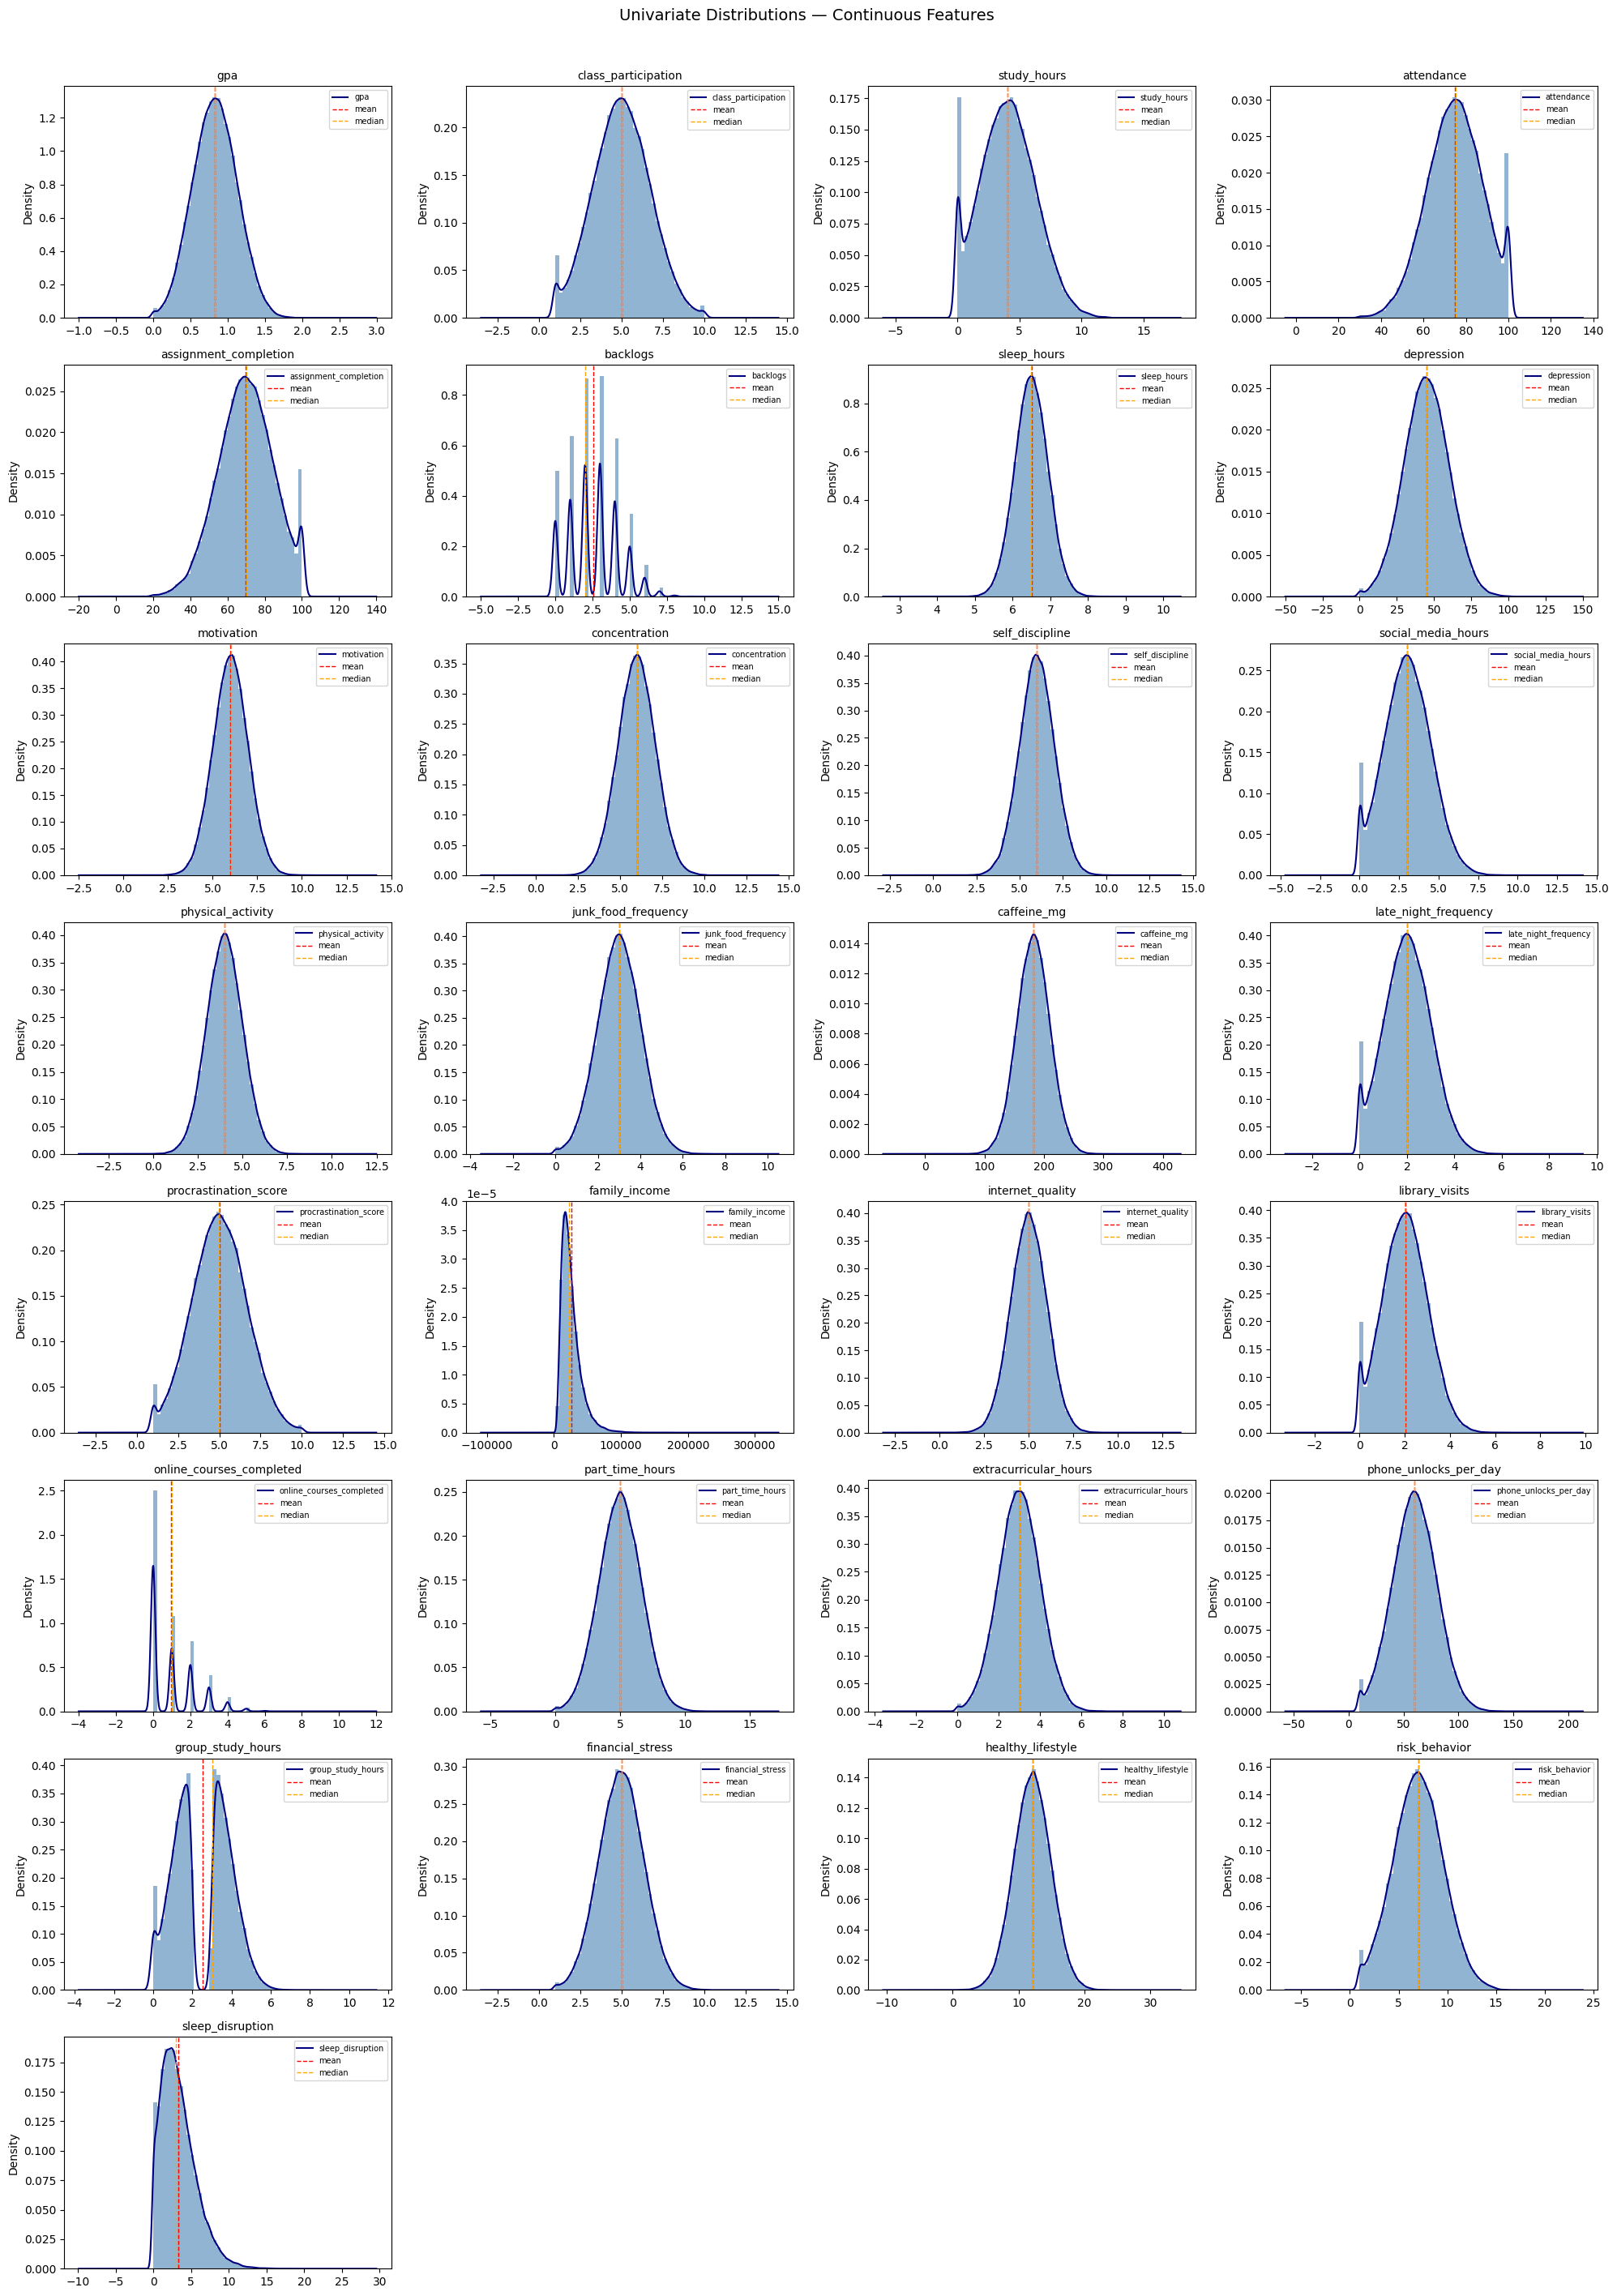

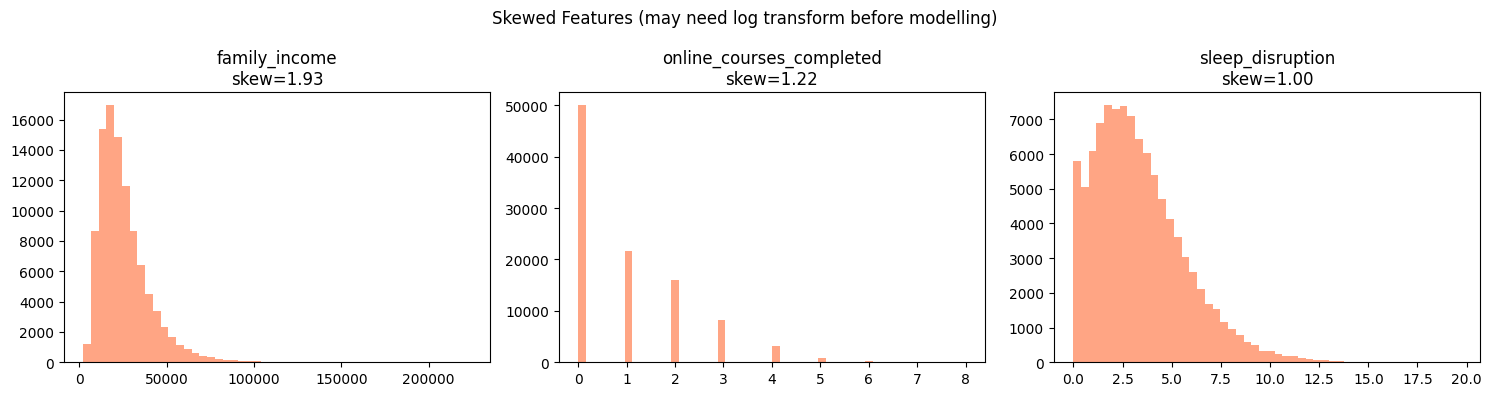

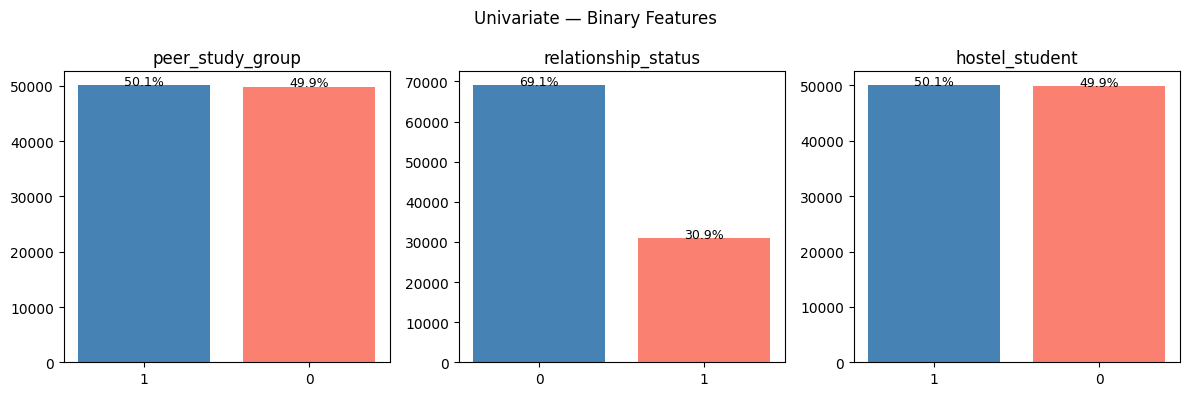

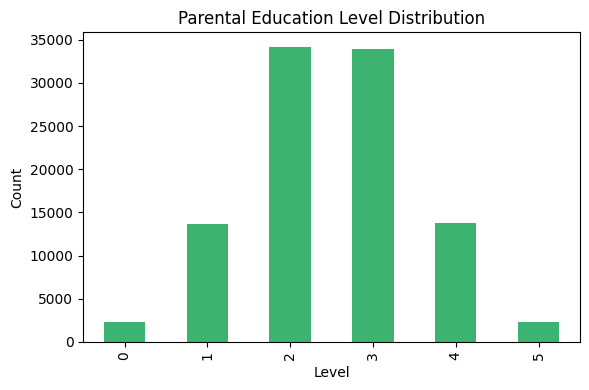

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Continuous variables ──────────────────────────────────────────────
continuous_cols = [
    'gpa', 'class_participation', 'study_hours', 'attendance', 'assignment_completion', 'backlogs',
    'sleep_hours', 'depression', 'motivation', 'concentration',
    'self_discipline', 'social_media_hours', 'physical_activity',
    'junk_food_frequency', 'caffeine_mg', 'late_night_frequency',
    'procrastination_score', 'family_income', 'internet_quality',
    'library_visits', 'online_courses_completed', 'part_time_hours',
    'extracurricular_hours', 'phone_unlocks_per_day', 'group_study_hours',
    'financial_stress',  'healthy_lifestyle',
    'risk_behavior', 'sleep_disruption'
]

# Summary stats table
summary = df_sample[continuous_cols].describe().T
summary['skewness'] = df_sample[continuous_cols].skew()
summary['kurtosis'] = df_sample[continuous_cols].kurt()
print(summary[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(2))

# Histograms + KDE for all continuous cols
n_cols = 4
n_rows = int(np.ceil(len(continuous_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_sample[col], bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='none')
    df_sample[col].plot.kde(ax=axes[i], color='navy', linewidth=1.5)
    axes[i].axvline(df_sample[col].mean(), color='red', linestyle='--', linewidth=1, label='mean')
    axes[i].axvline(df_sample[col].median(), color='orange', linestyle='--', linewidth=1, label='median')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Distributions — Continuous Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Skewed columns deserve special attention ──────────────────────────
skewed = ['family_income', 'online_courses_completed', 'sleep_disruption']

fig, axes = plt.subplots(1, len(skewed), figsize=(15, 4))
for ax, col in zip(axes, skewed):
    ax.hist(df_sample[col], bins=50, color='coral', edgecolor='none', alpha=0.7)
    ax.set_title(f'{col}\nskew={df_sample[col].skew():.2f}')
plt.suptitle("Skewed Features (may need log transform before modelling)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Binary variables ──────────────────────────────────────────────────
binary_cols = ['peer_study_group', 'relationship_status', 'hostel_student']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, binary_cols):
    counts = df_sample[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'salmon'])
    ax.set_title(col)
    for j, v in enumerate(counts.values):
        ax.text(j, v + 50, f'{v/len(df_sample)*100:.1f}%', ha='center', fontsize=9)
plt.suptitle("Univariate — Binary Features", fontsize=12)
plt.tight_layout()
plt.show()

# ── Ordinal variable ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
df_sample['parental_education_level'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='mediumseagreen', edgecolor='none'
)
ax.set_title("Parental Education Level Distribution")
ax.set_xlabel("Level")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Potential Leakage Check

Features with extremely high correlation with the target are inspected carefully.

In particular:

- `anxiety` shows an almost perfect correlation with `depression`
- `stress` also shows a very strong correlation with `depression`

These relationships may indicate that the variables are either:

- measuring nearly the same underlying construct as the target, or
- generated in a way that makes them unrealistically predictive in this dataset

Because the dataset appears synthetic and these variables may make prediction trivial, they should be treated as potential leakage candidates and reviewed before final model training.

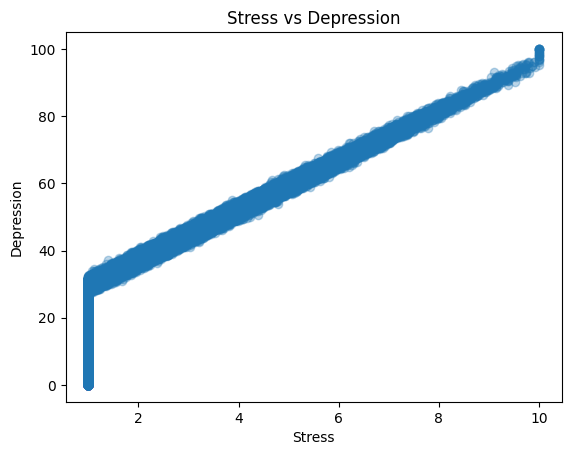

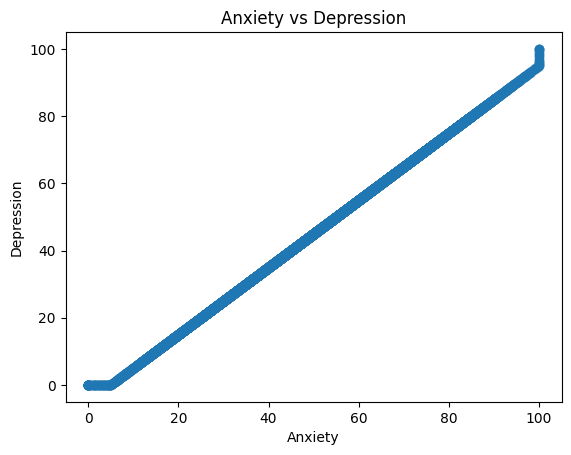

In [29]:
plt.scatter(df_sample["stress"], df_sample["depression"], alpha=0.3)
plt.title("Stress vs Depression")
plt.xlabel("Stress")
plt.ylabel("Depression")
plt.show()

# anxiety vs Depression

plt.scatter(df_sample["anxiety"], df_sample["depression"], alpha=0.3)
plt.title("Anxiety vs Depression")
plt.xlabel("Anxiety")
plt.ylabel("Depression")
plt.show()

### Conclusion

This step reduced redundancy by removing overlapping academic score variables and introduced a small number of exploratory composite features.

The updated correlation analysis shows that some predictors remain extremely strongly associated with `depression`, especially `anxiety` and `stress`. These variables should be removed as they represent potential leakage candidates, because they may make the model unrealistically easy in a synthetic dataset.


In [30]:
# 1. Drop non-informative column
df_sample.drop(columns=["performance_level"], inplace=True)

# 2. Drop redundant / derived / leakage columns
df_sample.drop(columns=[
    "netflix_hours",
    "screen_time",
    "gaming_hours",
    "anxiety",
    "stress"
], inplace=True)

# 3. Recheck missing values after column removal
print(df_sample.isnull().sum().sort_values(ascending=False).head(10))

study_hours              0
attendance               0
assignment_completion    0
backlogs                 0
sleep_hours              0
depression               0
motivation               0
concentration            0
time_management          0
self_discipline          0
dtype: int64


In [31]:
print("Full cleaned dataset shape:", df.shape)
print("Sample dataset shape:", df_sample.shape)
print("Number of columns in sample:", df_sample.shape[1])

Full cleaned dataset shape: (1000000, 42)
Sample dataset shape: (100000, 36)
Number of columns in sample: 36


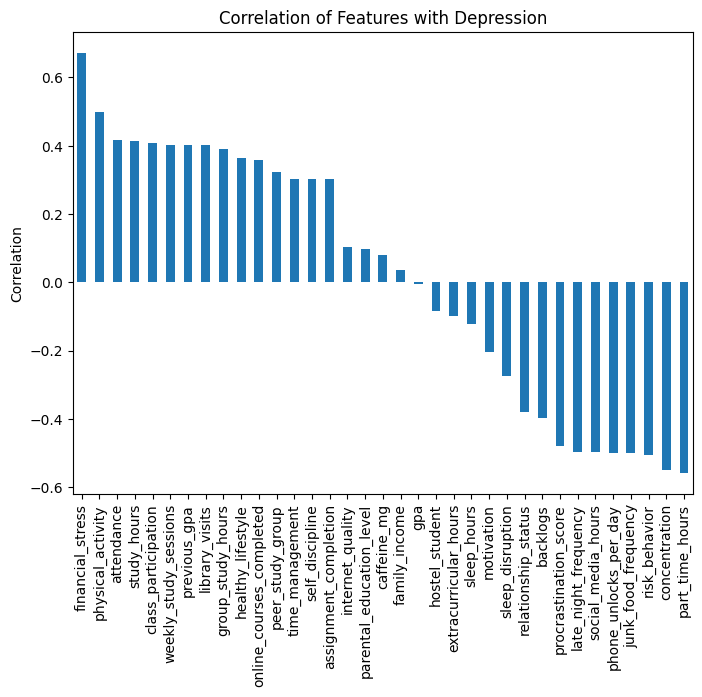

In [32]:
corr_target = df_sample.corr(numeric_only=True)["depression"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
corr_target.drop("depression").plot(kind="bar")
plt.title("Correlation of Features with Depression")
plt.ylabel("Correlation")
plt.show()

## Step 19: Visualize Key Relationships with Depression

In this step, selected numerical features are visualized against the target variable (`depression`) using scatter plots.

The goal is to explore whether the relationships observed in the correlation analysis are reflected in the raw data. This helps verify the direction, strength, and nature of the relationships between key academic, lifestyle, and behavioral variables and depression.

Some of the features represent different aspects of student life:

- `sleep_hours` → lifestyle and well-being  
- `financial_stress` → psychological and economic pressure  
- `social_media_hours` → behavioral habits  
- `motivation` → academic and mental state  

Scatter plots are used to observe:

- the direction of the relationship (positive or negative)
- the strength of the association
- the spread and variability of the data
- whether the relationship appears linear or more complex

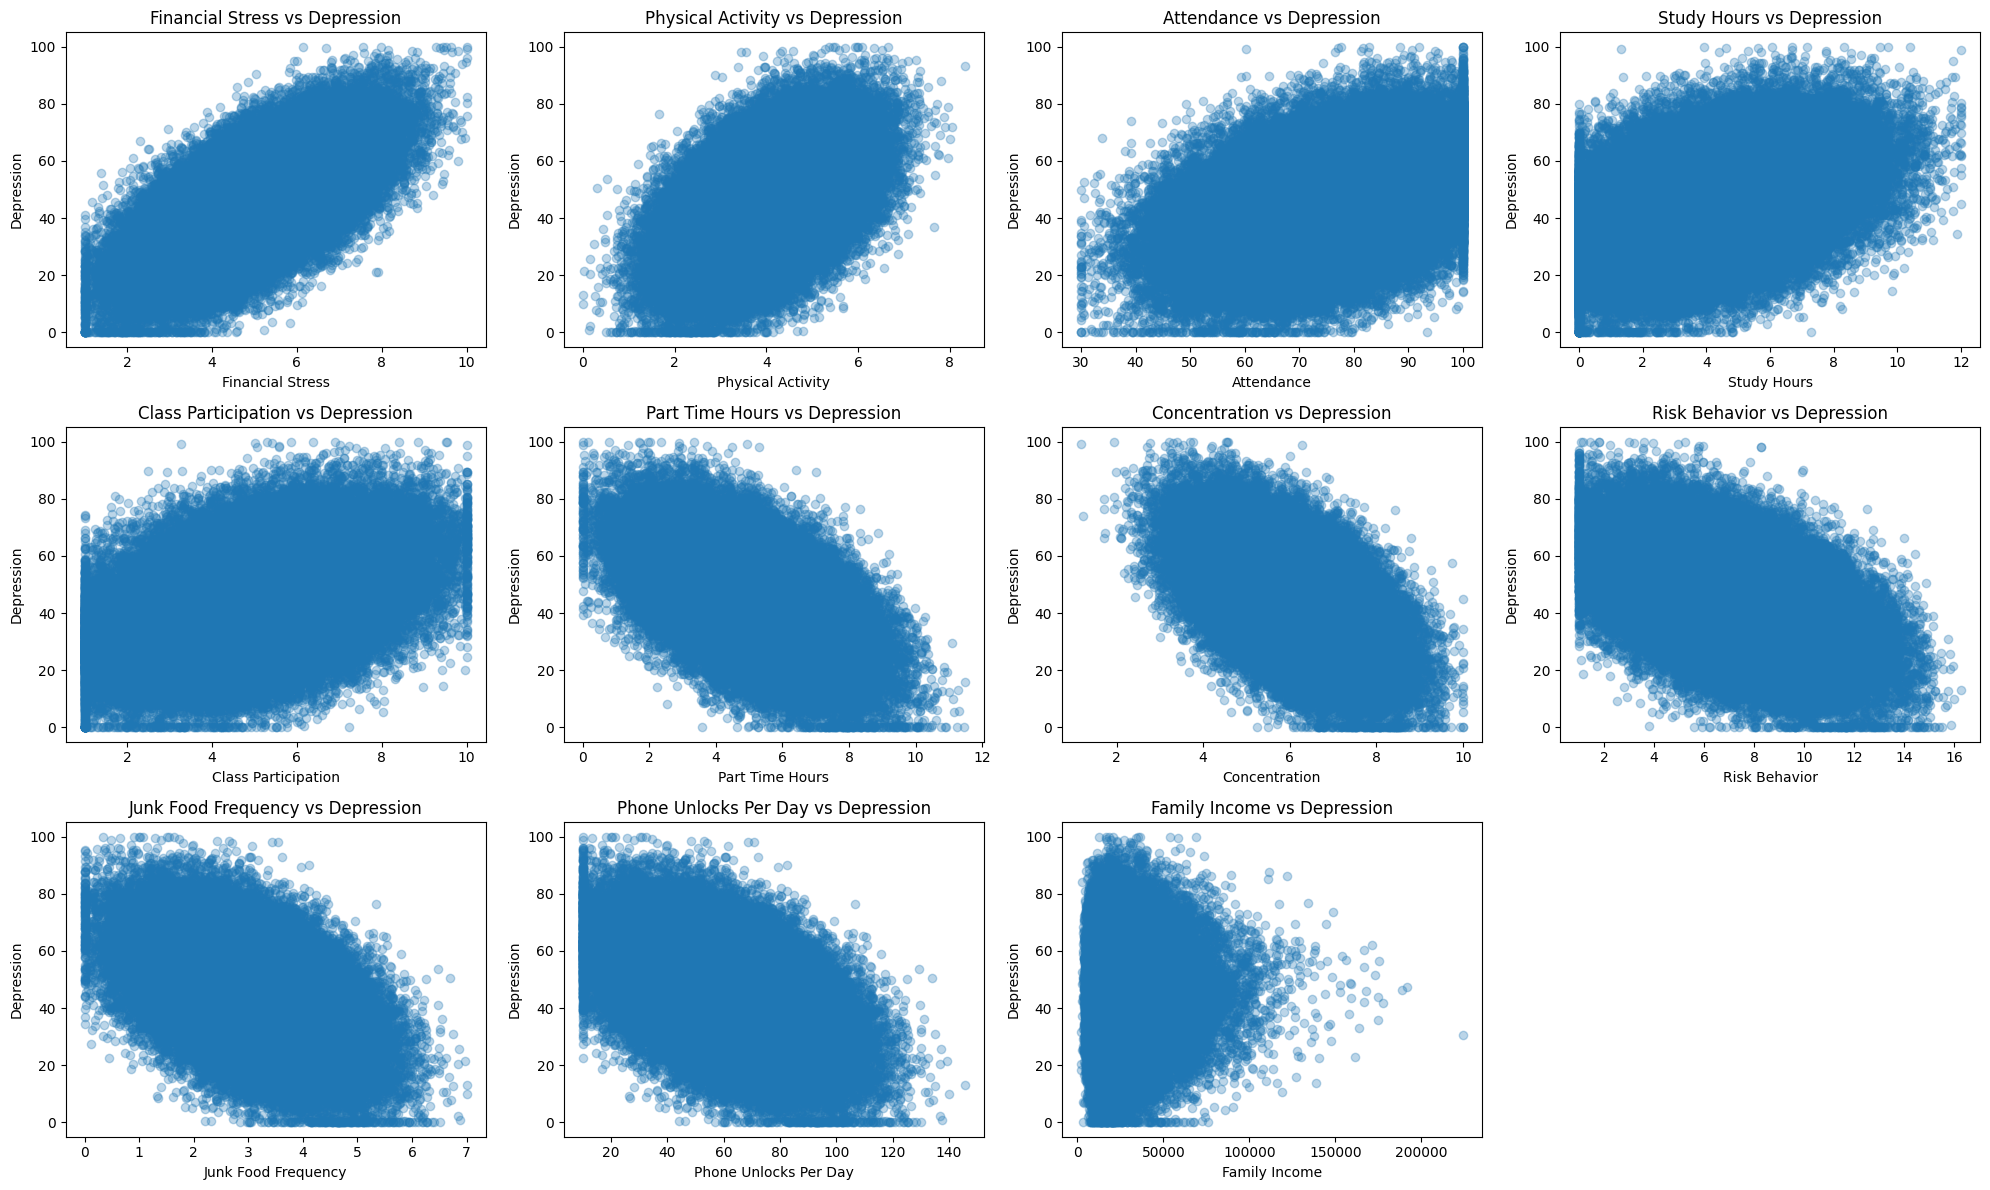

In [33]:
import matplotlib.pyplot as plt
import math

features_to_plot = [
    "financial_stress",
    "physical_activity",
    "attendance",
    "study_hours",
    "class_participation",
    "part_time_hours",
    "concentration",
    "risk_behavior",
    "junk_food_frequency",
    "phone_unlocks_per_day",
    "family_income"
]

# Number of columns
cols = 4

# Compute number of rows needed
rows = math.ceil(len(features_to_plot) / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()  # Flatten for easy indexing

for i, feature in enumerate(features_to_plot):
    axes[i].scatter(df_sample[feature], df_sample["depression"], alpha=0.3)
    axes[i].set_xlabel(feature.replace("_", " ").title())
    axes[i].set_ylabel("Depression")
    axes[i].set_title(f"{feature.replace('_', ' ').title()} vs Depression")

# Remove empty plots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

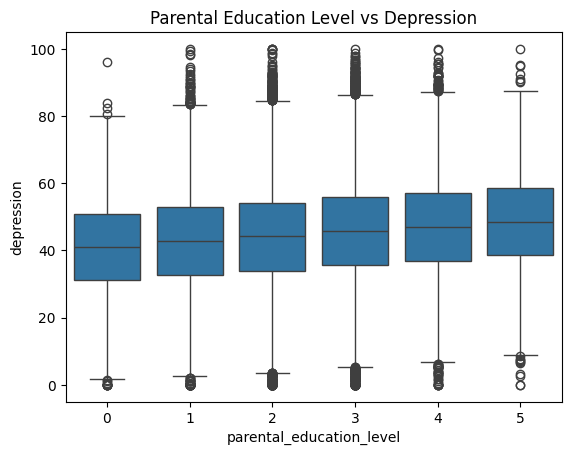

In [34]:
sns.boxplot(x="parental_education_level", y="depression", data=df_sample)
plt.title("Parental Education Level vs Depression")
plt.show()

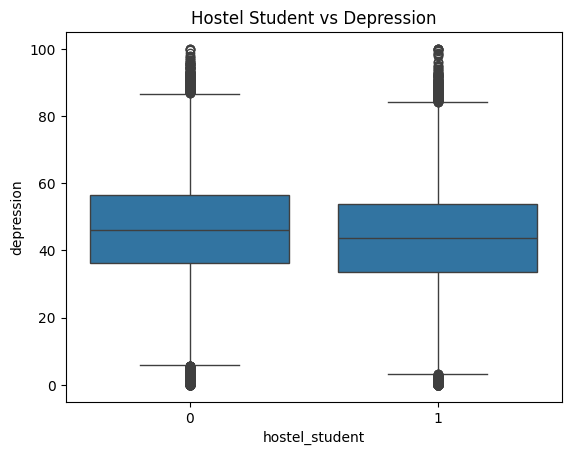

In [35]:
sns.boxplot(x="hostel_student", y="depression", data=df_sample)
plt.title("Hostel Student vs Depression")
plt.show()

## Feature Selection (Domain-Driven Approach)

Instead of relying purely on statistical correlation, we selected features based on their relevance to mental health and psychological well-being.

The following features were chosen:
- Motivation
- Concentration
- Self Discipline
- Financial Stress

These variables are directly related to known psychological and behavioral factors influencing depression.

### Why Not Use All Features?
- Some features caused data leakage (e.g., Stress, Anxiety)
- Some features were redundant (e.g., self_discipline ≡ time_management)
- Others were less directly related with mental health
- Using a smaller, meaningful subset improves interpretability, as our general approach was to see the effects of different aspects on depression.

### Validation Step
Although the selection is domain-driven, we validate that these features have strong relationships with the target variable.

In [36]:
selected_features = [
"motivation",
"concentration",
#"time_management", dropped because it is identical to self_discipline
"self_discipline",
"financial_stress"
]

df_model = df_sample[selected_features].copy()

print("Modeling dataset shape:", df_model.shape)
print("Selected features:")
print(selected_features)

Modeling dataset shape: (100000, 4)
Selected features:
['motivation', 'concentration', 'self_discipline', 'financial_stress']


## Problem Formulation

The original target variable `depression` is continuous. However, for this project, we convert it into a binary classification problem.

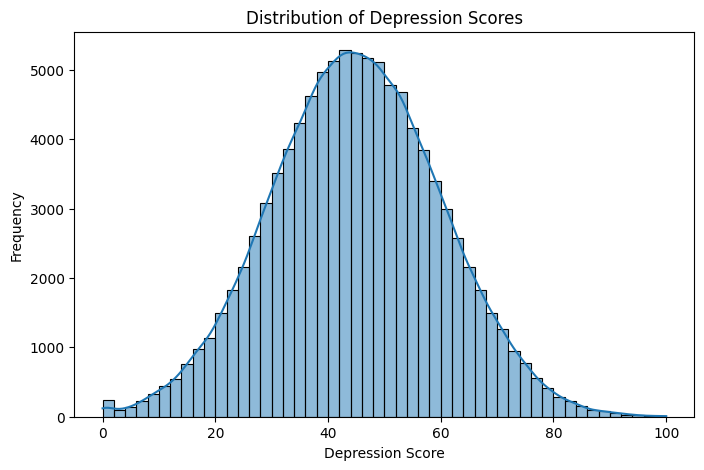

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(df_sample["depression"], bins=50, kde=True)
plt.title("Distribution of Depression Scores")
plt.xlabel("Depression Score")
plt.ylabel("Frequency")
plt.show()

### Why Classification Instead of Regression?
- Classification is more interpretable for decision-making (e.g., identifying at-risk students)
- Easier to evaluate using metrics like accuracy, recall, and ROC-AUC
- More aligned with real-world screening systems

### Threshold Selection

Instead of choosing an arbitrary threshold, we use a **data-driven approach** based on the distribution of the depression scores.

In [38]:
threshold = df_sample["depression"].median()
threshold

np.float64(44.9007665)

In [39]:
df_model["depression_binary"] = (df_sample["depression"] >= threshold).astype(int)
print(df_model["depression_binary"].value_counts(normalize=True) * 100)

depression_binary
0    50.0
1    50.0
Name: proportion, dtype: float64


In [40]:
print("Full cleaned dataset shape:", df.shape)
print("Model dataset shape:", df_model.shape)

Full cleaned dataset shape: (1000000, 42)
Model dataset shape: (100000, 5)


The threshold was chosen based on the median of the depression score distribution to ensure a balanced and meaningful classification of high-risk individuals.

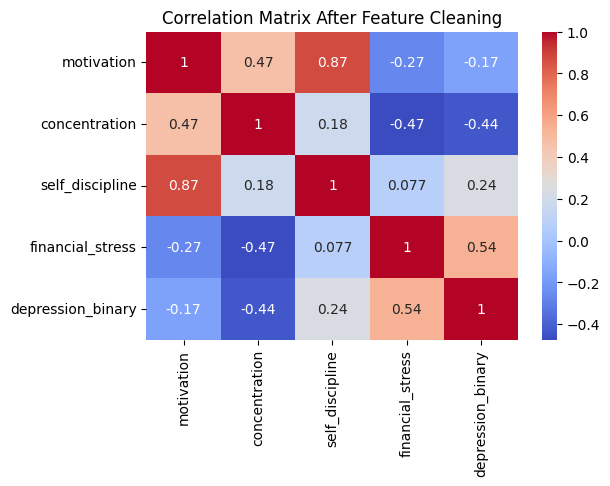

In [41]:
# Recompute correlations after feature updates
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix After Feature Cleaning")
plt.show()

In [42]:
df_model.corr(numeric_only=True)["depression_binary"].sort_values(ascending=False)

depression_binary    1.000000
financial_stress     0.536652
self_discipline      0.239995
motivation          -0.165711
concentration       -0.435803
Name: depression_binary, dtype: float64

In [43]:
from sklearn.model_selection import train_test_split

X = df_sample[selected_features]
y = df_model["depression_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # VERY important for classification
)

## Train-Test Split

The dataset was split into training (80%) and testing (20%) sets.

Stratified sampling was used to preserve the class distribution in both sets, ensuring reliable evaluation.

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

## Feature Scaling

Standardization was applied using `StandardScaler` to normalize feature distributions.

The scaler was fit only on the training data and then applied to the test data to prevent data leakage.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"\n{name}")
    print(classification_report(y_test, preds))



results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     10000
           1       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000


Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10000
           1       0.95      0.95      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9989,0.998900,0.9989,0.998900,0.999994
1,Random Forest,0.9842,0.984394,0.9840,0.984197,0.999126
2,Gradient Boosting,0.9495,0.949051,0.9500,0.949525,0.992340


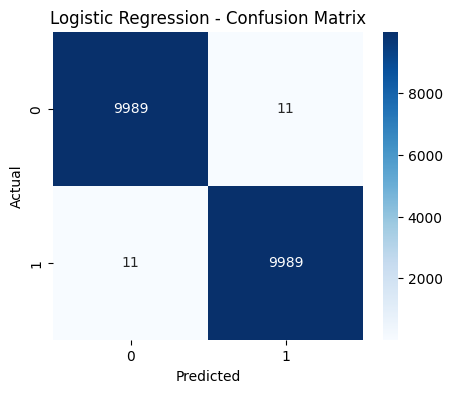

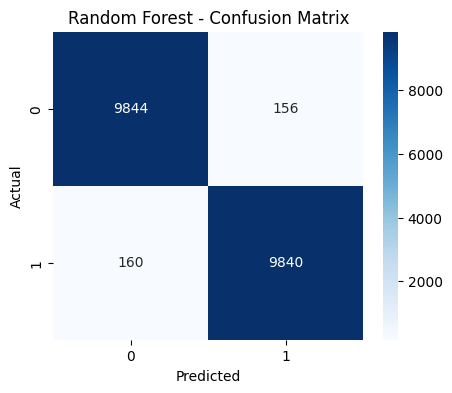

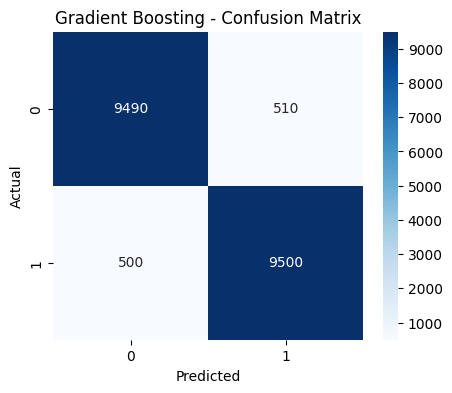

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    preds = model.predict(X_test)
    
    cm = confusion_matrix(y_test, preds)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

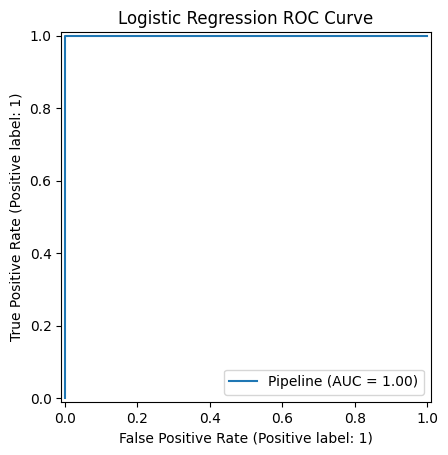

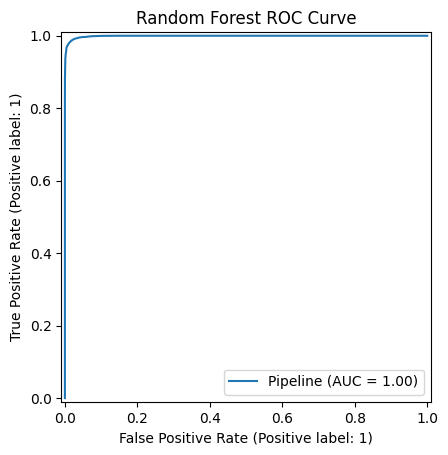

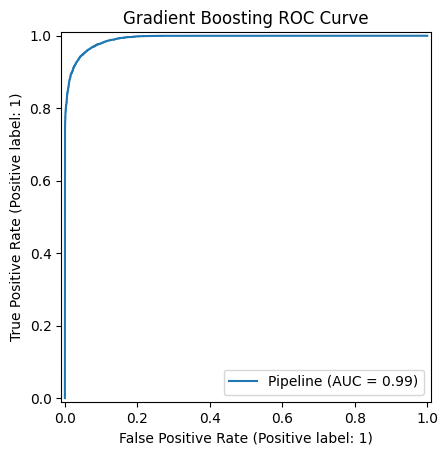

In [48]:
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} ROC Curve")
    plt.show()

In [49]:
best_model = models["Random Forest"]  # or whichever performed best

importances = best_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
2,self_discipline,0.328764
0,motivation,0.308735
3,financial_stress,0.234515
1,concentration,0.127987


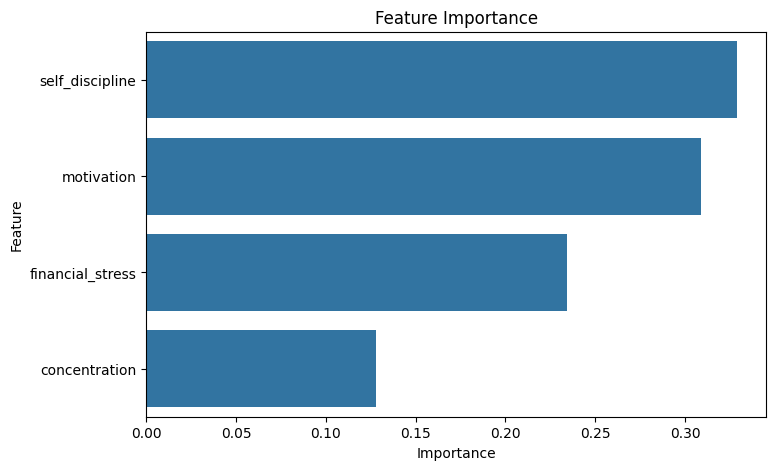

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

## Model Interpretation

The feature importance analysis reveals the key factors influencing depression:

- **Self discipline**: The most significant predictor, indicating that self-regulation behavior is strongly associated with increased depression levels.
- **Motivation**: Lower motivation levels are linked to higher depression risk.
- **Financial stress**: Higher financial stress is associated with stress and depression.
- **Concentration**: Difficulty concentrating is a strong indicator of mental health struggles.

This aligns with real-world understanding of mental health, where both internal and external factors contribute to depression.
Our study focuses on the mental & cognitive factors from this dataset, with some factors being dropped because they are extremely correlated with depression and cause a data leakage. 

In [51]:
log_model = models["Logistic Regression"]

coeffs = log_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coeffs
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
2,self_discipline,37.368519
0,motivation,-36.377756
3,financial_stress,0.128558
1,concentration,-0.051924


### Logistic Regression Interpretation

Positive coefficients indicate features that increase the likelihood of depression, while negative coefficients indicate protective factors.

This provides additional interpretability compared to tree-based models.

## Conclusion

In this dataset, we investigated factors influencing depression among students using domain-driven feature selection and multiple machine learning models. Key findings include:

- **Self Discipline & Motivation** emerged as the strongest predictors of depression, highlighting the impact of behavioural aspects.  
- **Financial Stress** External stresses also contribute with the prediction of depression.  

The Random Forest model provided the best performance with the highest ROC-AUC, confirming that tree-based models can effectively capture complex interactions among mental health variables.

Overall, the study demonstrates that **both psychological and external stress factors contribute significantly to depression**, and these insights can guide early intervention and support strategies for students.

## Limitations

While this study provides valuable insights, there are some limitations:

1. **Synthetic Dataset**: The data has been synthetically made, and it has poorly made relations between features, which caused a major issue when handeling the data, which is data leakage, and the extremely high accuracy, therefore, we couldn't realistically answer the hypothesis questions.
2. **Threshold Selection**: The depression classification threshold, though data-driven, may still oversimplify a continuous outcome.  
3. **Feature Coverage**: Only selected mental health factors were analyzed; other potentially important variables (sleep, social behavior, physical activity) were excluded, as they are to be coverd from the other datasets.  

One of the main challenges that we met during handling this dataset is unrealistic relations between features, as an example, after we did the modelling and the results came, the relation between 'Self discipline' and depression is a positive coefficient, which means the more the self discipline a person has the more likely he has depression, which realistically doesn't make any sense.

In [ ]:
from joblib import dump, load
import os

save_dir = r"C:\Users\samak\Desktop\Machinelearning project\Student_depression\ml-project\backend\saved_models"

# make sure folder exists
os.makedirs(save_dir, exist_ok=True)

# full path for model B
model_path = os.path.join(save_dir, "model_b.pkl")

# save model
dump(models["Random Forest"], model_path)

print(f"✓ Model B saved at: {model_path}")

# optional: test loading
rf_model_loaded = load(model_path)
print("✓ Model B loaded successfully")